#*Import Library & Load Dataset*

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# setting visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# load data
df = pd.read_csv('breast_cancer_data.csv')

# lihat 5 data pertama
df.head()

,Age,Gender,Family History,Dietary Habit,Radius,Texture,Perimeter,Area,Compactness,Concavity,Concave Points,Symmetry,Diagnosis
0,83,Female,No,Bad,12.59,27.20,75.58,478.92,0.2462,0.2443,0.0634,0.2035,Benign
1,35,Female,Yes,Good,29.00,27.54,185.73,2831.55,0.1058,0.2934,0.0943,0.1425,Malignant
2,81,Female,Yes,Good,13.43,21.76,78.05,609.84,0.2997,0.2113,0.1957,0.2697,Benign
3,20,Female,No,Good,10.21,38.22,61.60,333.74,0.1605,0.1887,0.1675,0.1585,Benign
4,47,Female,No,Bad,17.85,20.40,112.63,1008.39,0.1977,0.3115,0.0533,0.2050,Benign


#*Dataset Structure*

In [4]:
# info dataset
df.info()

# ukuran dataset
df.shape

# nama kolom
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             5000 non-null   int64  
 1   Gender          5000 non-null   object 
 2   Family History  5000 non-null   object 
 3   Dietary Habit   5000 non-null   object 
 4   Radius          5000 non-null   float64
 5   Texture         5000 non-null   float64
 6   Perimeter       5000 non-null   float64
 7   Area            5000 non-null   float64
 8   Compactness     5000 non-null   float64
 9   Concavity       5000 non-null   float64
 10  Concave Points  5000 non-null   float64
 11  Symmetry        5000 non-null   float64
 12  Diagnosis       5000 non-null   object 
dtypes: float64(8), int64(1), object(4)
memory usage: 507.9+ KB


Index(['Age', 'Gender', 'Family History', 'Dietary Habit', 'Radius', 'Texture',
       'Perimeter', 'Area', 'Compactness', 'Concavity', 'Concave Points',
       'Symmetry', 'Diagnosis'],
      dtype='object')

#*Missing Values Checking*

In [5]:
df.isnull().sum()

,0
Age,0
Gender,0
Family History,0
Dietary Habit,0
Radius,0
Texture,0
Perimeter,0
Area,0
Compactness,0
Concavity,0


#*Descriptive Statistics*

In [6]:
df.describe()

,Age,Radius,Texture,Perimeter,Area,Compactness,Concavity,Concave Points,Symmetry
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,52.02520,17.559710,24.887546,110.274446,1135.391278,0.161694,0.199445,0.100382,0.200634
std,18.68532,7.246743,8.694899,46.042065,821.063005,0.080064,0.115275,0.057592,0.057881
min,20.00000,5.000000,10.000000,28.330000,73.890000,0.020000,0.000000,0.000000,0.100000
25%,36.00000,11.397500,17.550000,70.685000,402.132500,0.093775,0.098575,0.050375,0.149575
50%,52.00000,17.440000,24.770000,109.375000,955.825000,0.162100,0.200000,0.100100,0.201050
75%,69.00000,23.900000,32.342500,148.677500,1789.927500,0.230100,0.298800,0.151500,0.249525
max,84.00000,30.000000,40.000000,206.050000,3085.810000,0.300000,0.400000,0.200000,0.300000


#*Parameters Encoding*

In [23]:
#Gender Encoding
df['gender'] = df['Gender'].map({
    'Female': 0,
    'Male': 1
})

#Diagnosis Encoding
df['diagnosis'] = df['Diagnosis'].map({
    'Benign': 0,
    'Malignant': 1
})


#*Target Distribution*

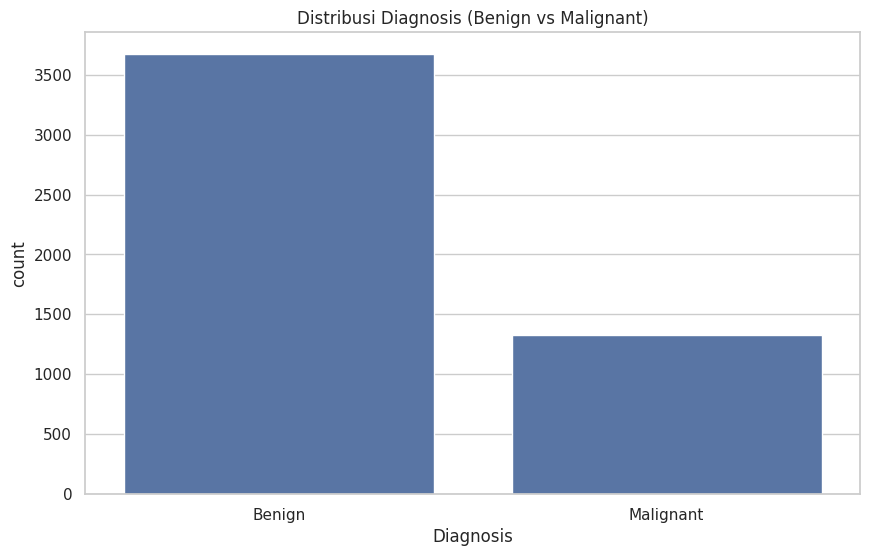

In [8]:
sns.countplot(x='Diagnosis', data=df)
plt.title('Distribusi Diagnosis (Benign vs Malignant)')
plt.show()

#*Feature Distribution*

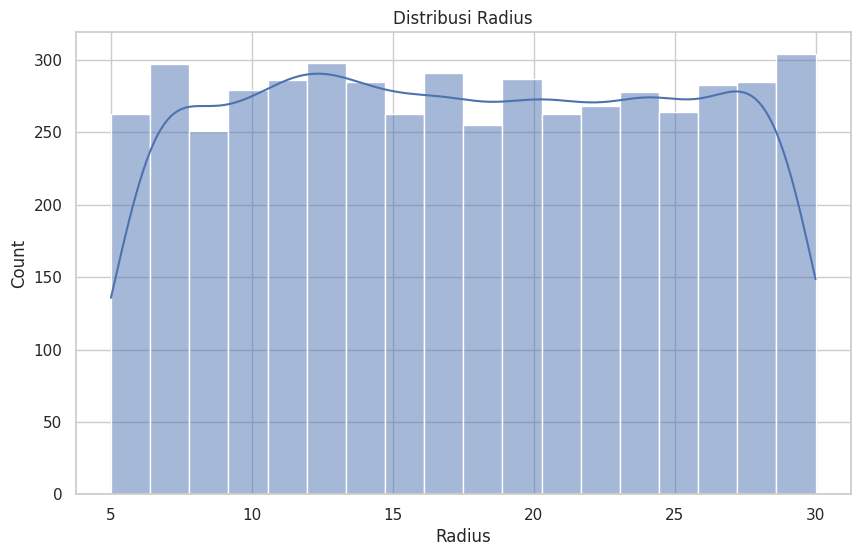

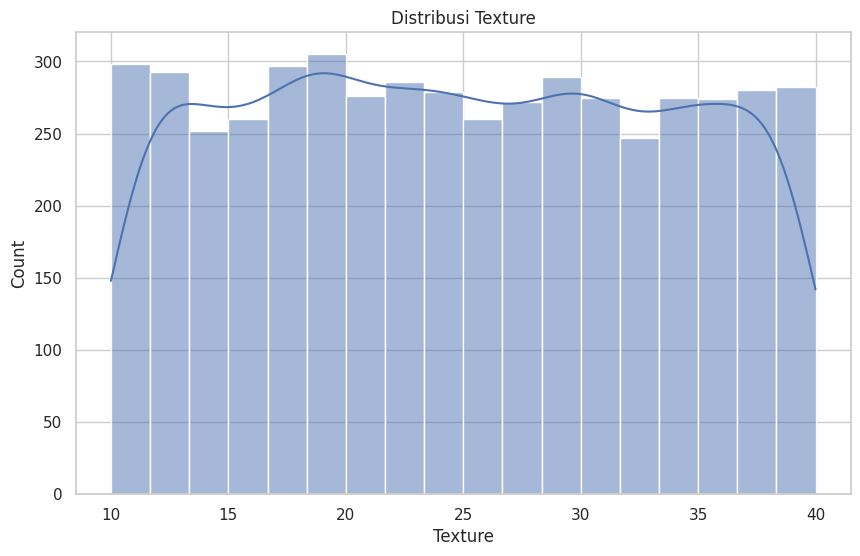

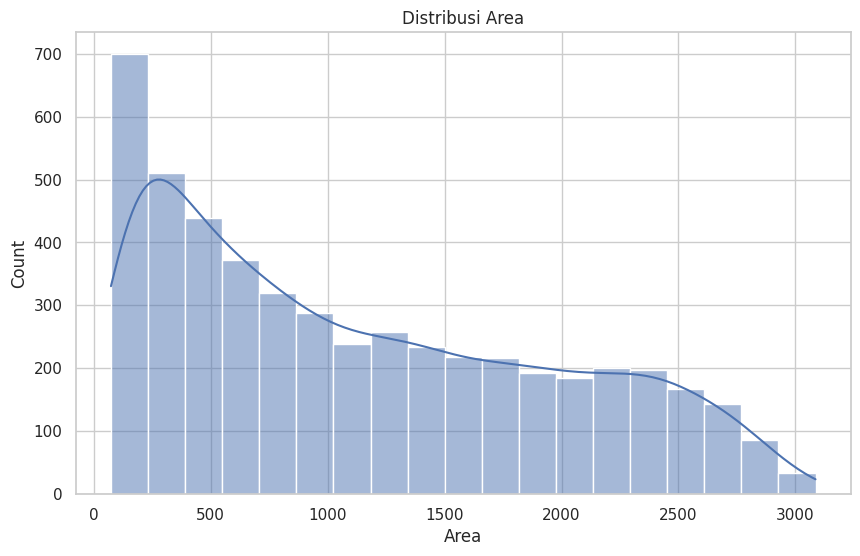

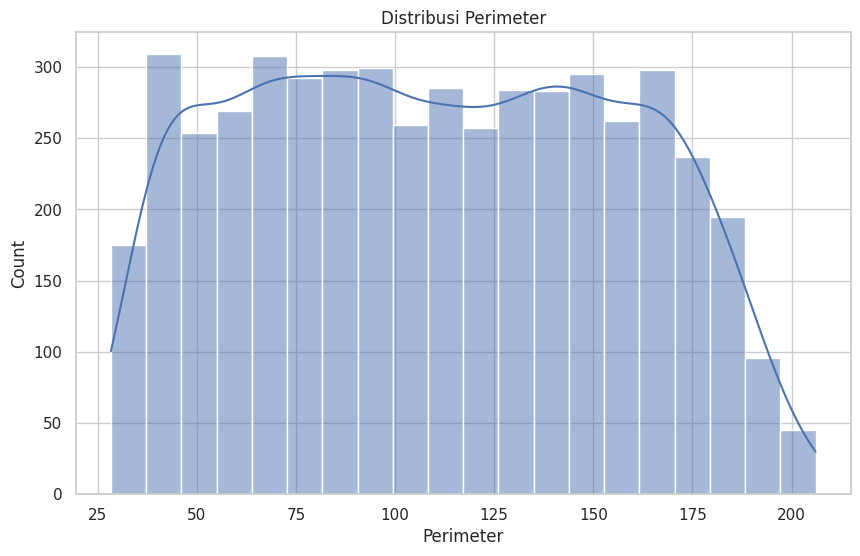

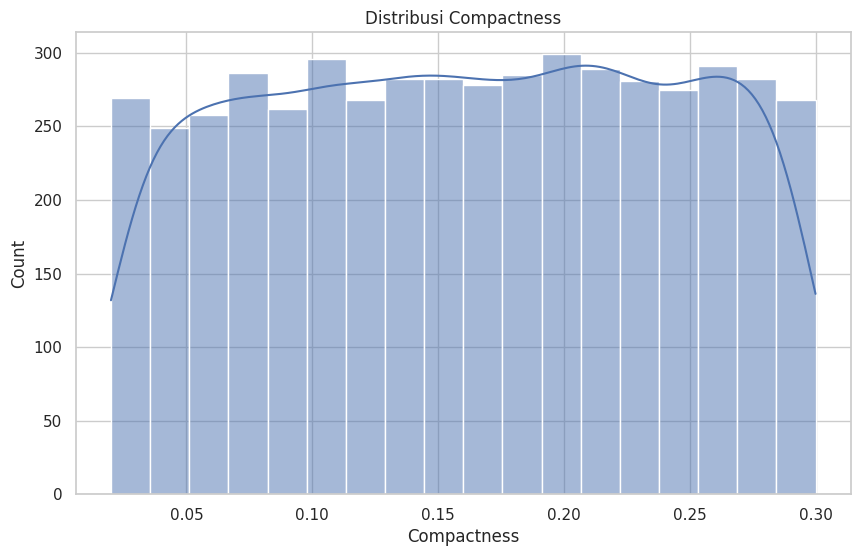

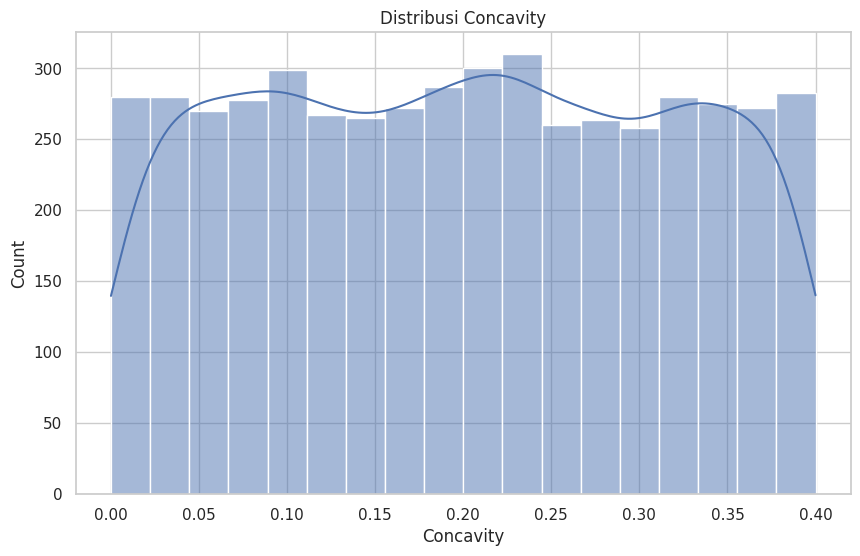

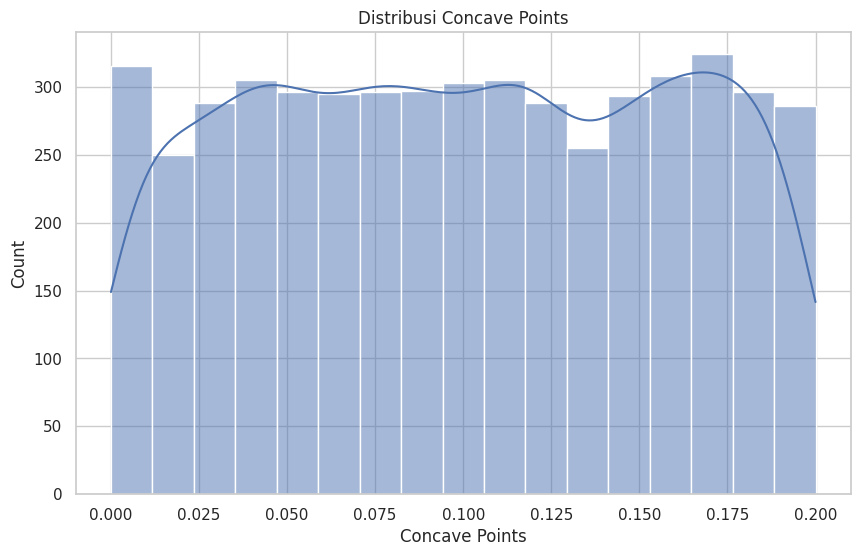

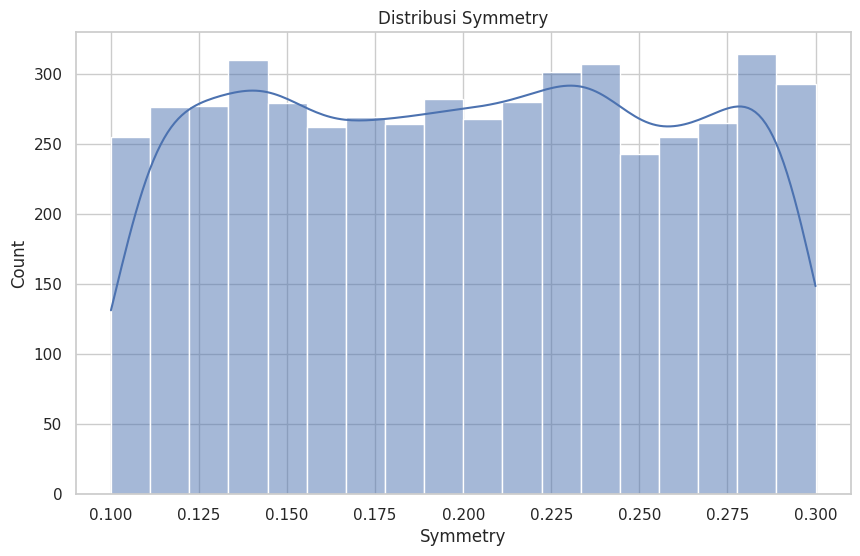

In [10]:
features = ['Radius', 'Texture', 'Area', 'Perimeter',
            'Compactness', 'Concavity', 'Concave Points', 'Symmetry']

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()

#*Comparison Based on Diagnosis*

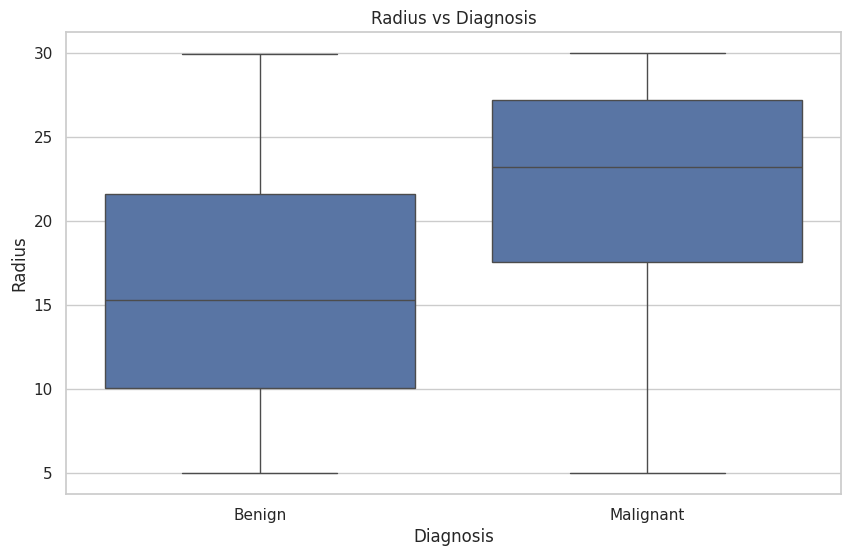

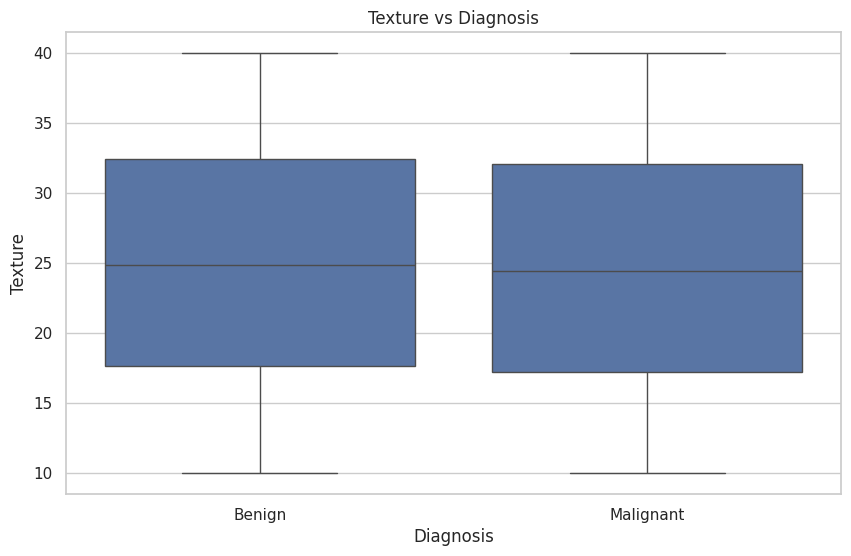

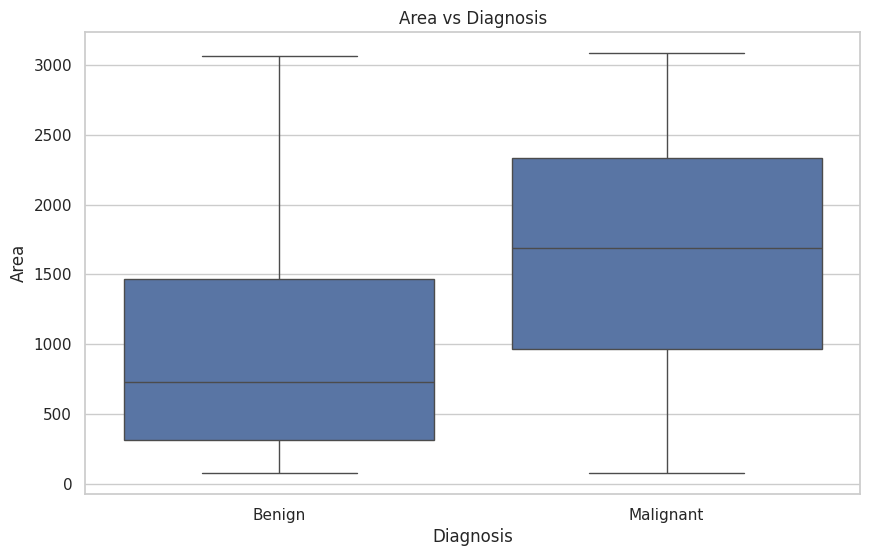

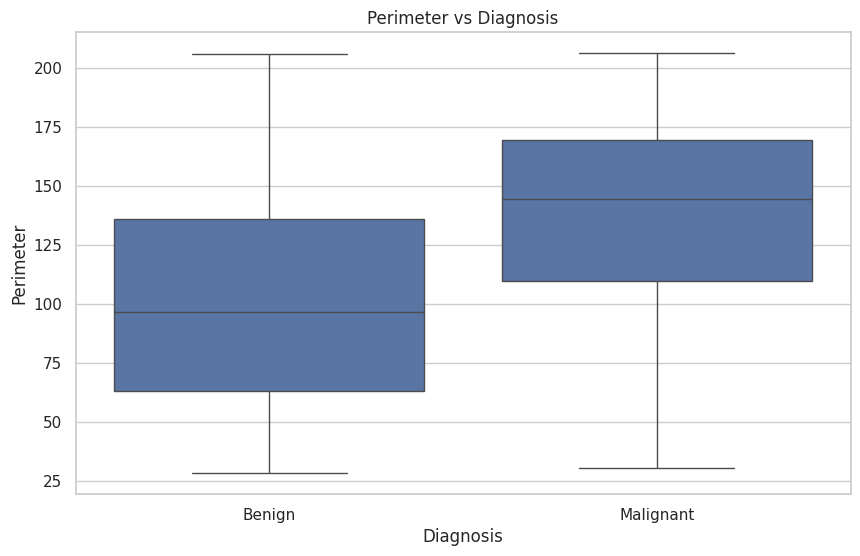

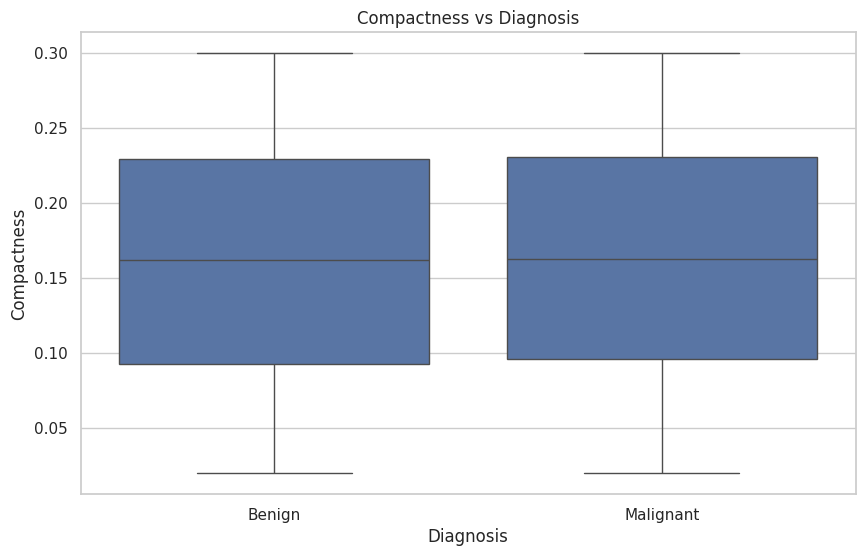

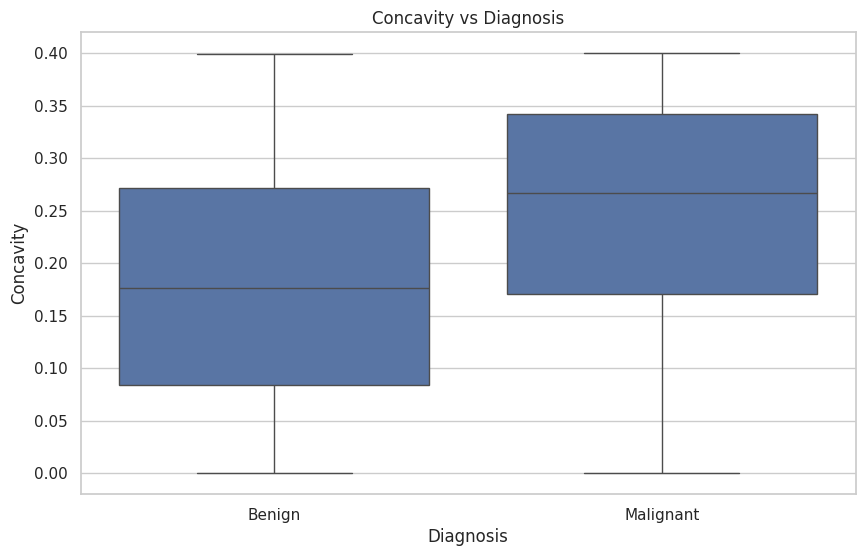

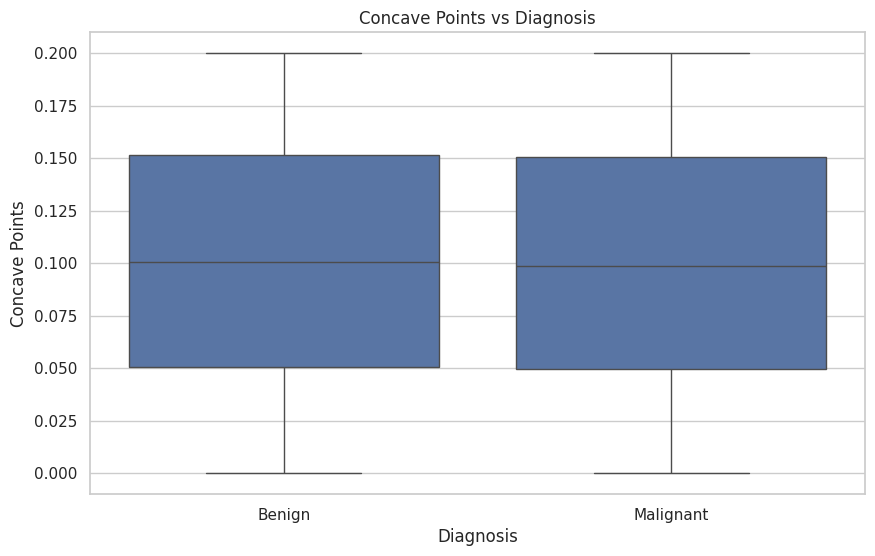

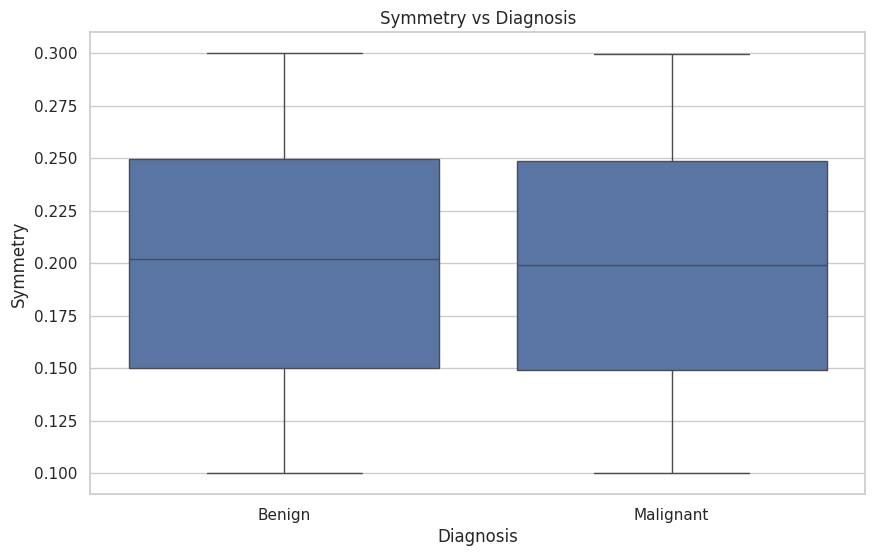

In [12]:
for col in features:
    plt.figure()
    sns.boxplot(x='Diagnosis', y=col, data=df)
    plt.title(f'{col} vs Diagnosis')
    plt.show()

#*Correlation Between Features*

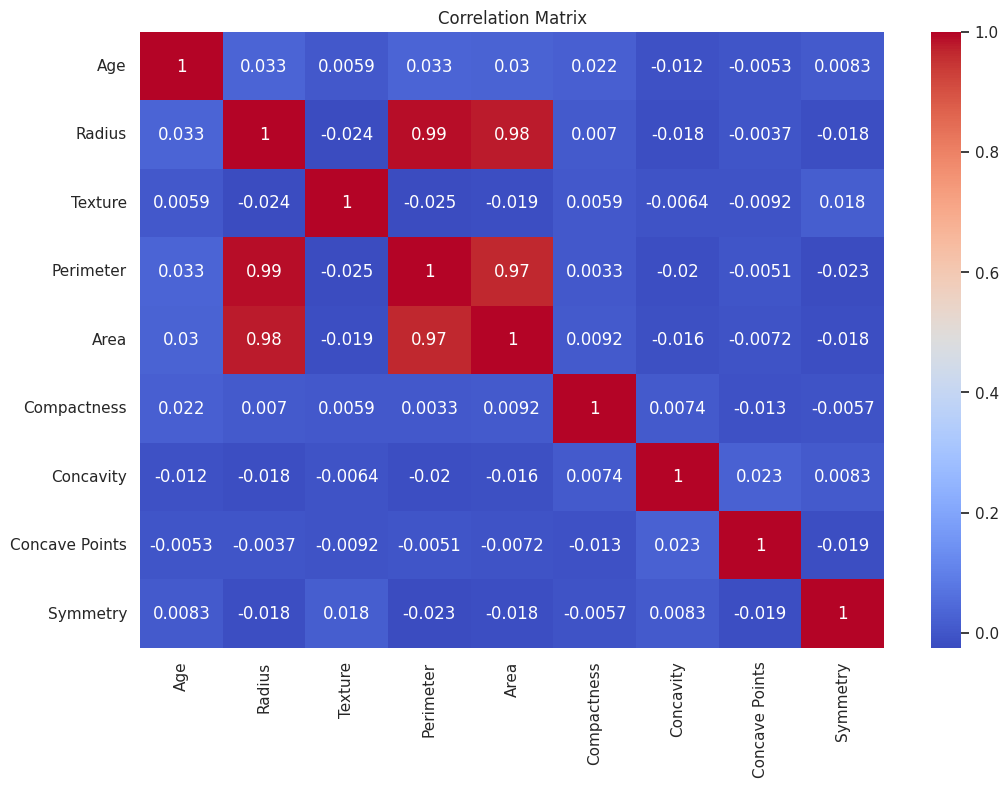

In [27]:
corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [19]:
df.columns

Index(['Age', 'Gender', 'Family History', 'Dietary Habit', 'Radius', 'Texture',
       'Perimeter', 'Area', 'Compactness', 'Concavity', 'Concave Points',
       'Symmetry', 'Diagnosis'],
      dtype='object')

#*Correlation to Target*

In [32]:
# ambil hanya kolom numerik
numeric_df = df.select_dtypes(include=['number'])

corr_target = numeric_df.corr()['diagnosis'].sort_values(ascending=False)
print(corr_target)

diagnosis         1.000000
Area              0.363591
Radius            0.359083
Perimeter         0.354220
Concavity         0.259217
Age               0.235175
Compactness       0.013059
Concave Points   -0.007551
Symmetry         -0.009610
Texture          -0.018488
gender           -0.023158
Name: diagnosis, dtype: float64


#*Pair Plot*

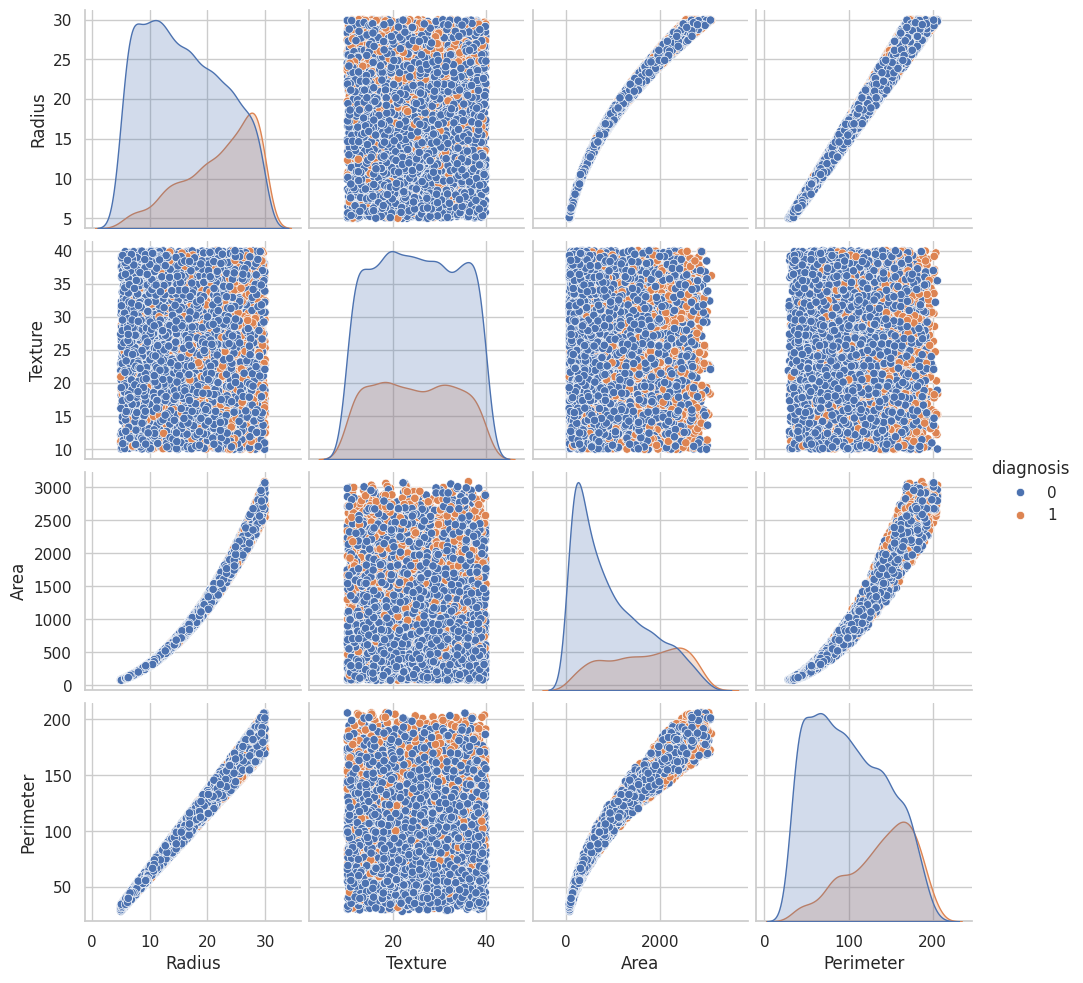

In [33]:
sns.pairplot(df, hue='diagnosis', vars=features[:4])
plt.show()

#*Outlier Detection*

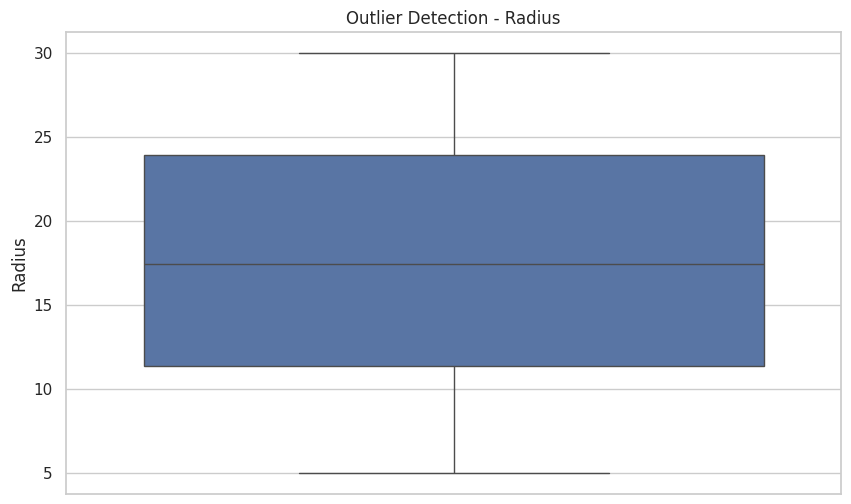

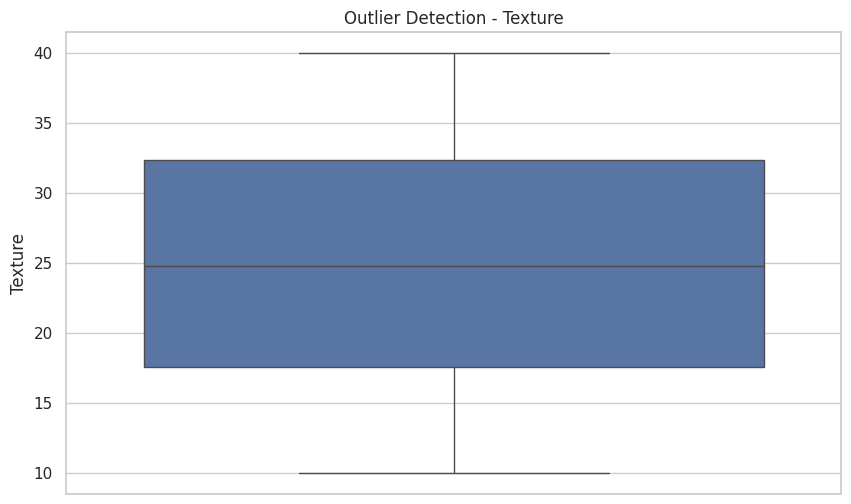

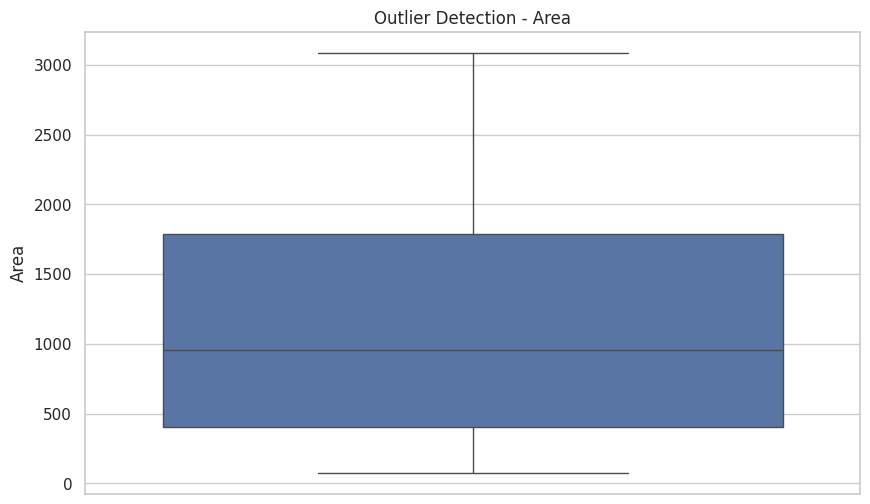

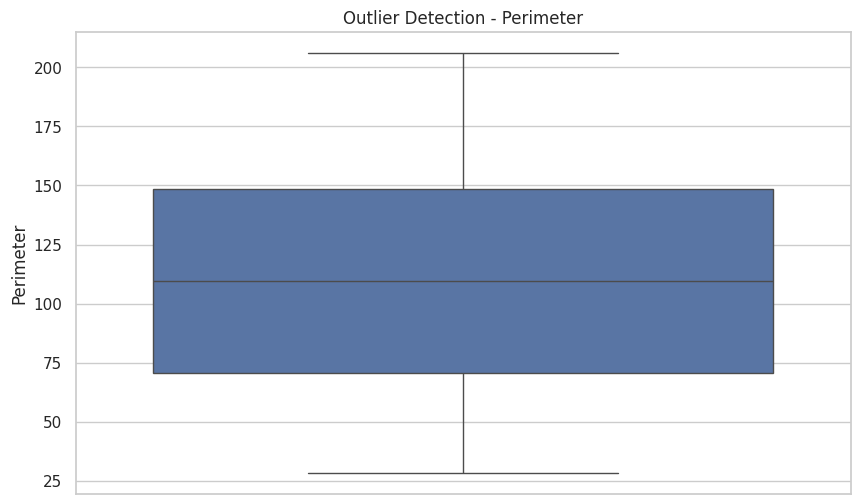

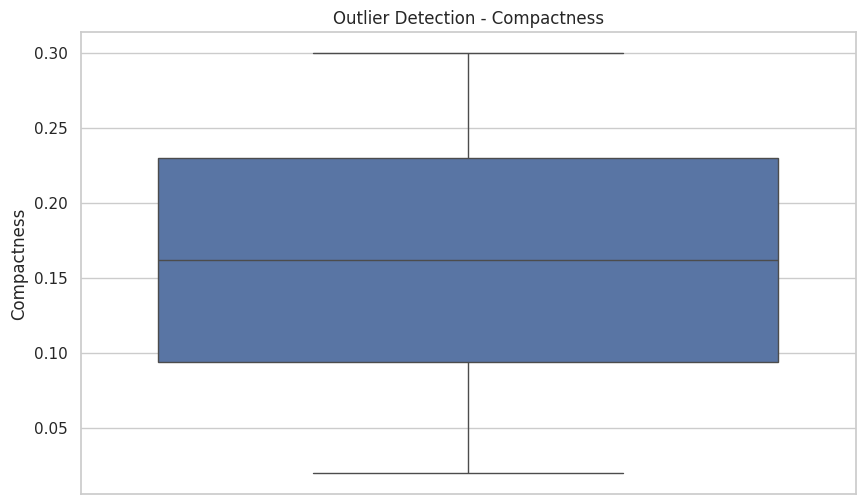

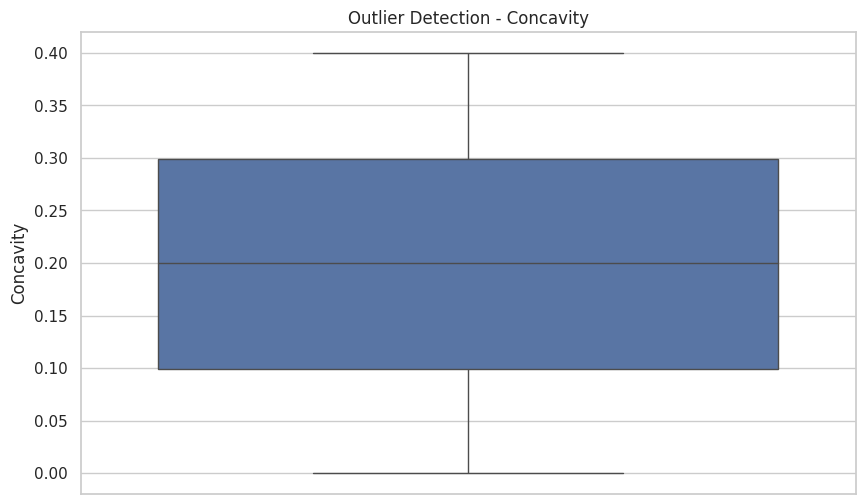

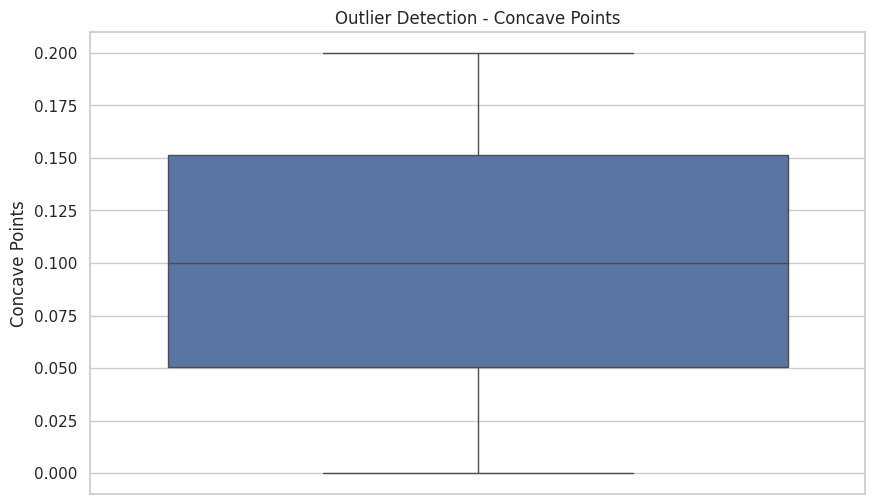

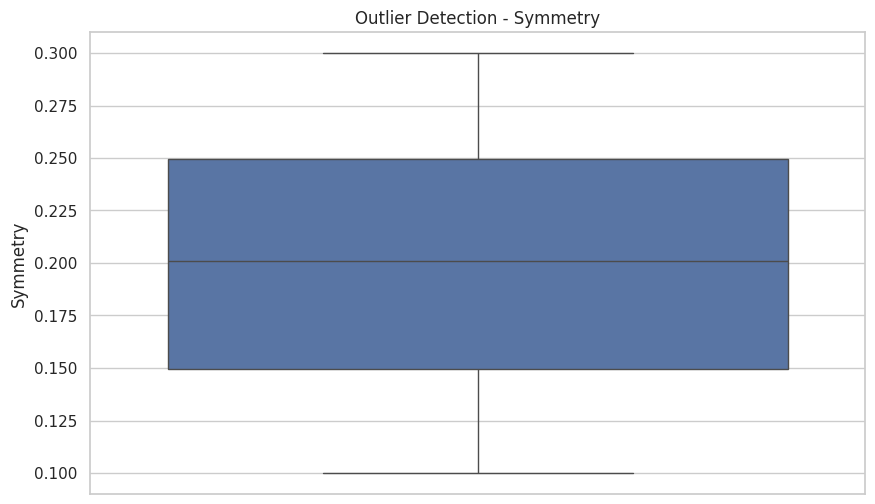

In [36]:
for col in features:
    plt.figure()
    sns.boxplot(data=df[col])
    plt.title(f'Outlier Detection - {col}')
    plt.show()

The data distribution shows that benign cases outnumber malignant cases, indicating class imbalance in the dataset. This is important to note as it can impact model performance, particularly in predicting minority classes. The distribution of features such as radius, texture, area, and perimeter shows a relatively even distribution, although some features, such as area and perimeter, tend to be slightly skewed to the right. Furthermore, based on distribution visualizations and boxplots, the data generally show no significant outliers, so the data quality can be considered clean and stable enough to be used in modeling without the need for complex outlier handling.

Correlation analysis revealed that features such as area, radius, and perimeter have a strong correlation with the diagnostic target, indicating that cell size and geometric characteristics play a significant role in distinguishing benign and malignant tumors. Furthermore, very high correlations were found between several features, such as radius–perimeter and radius–area, indicating multicollinearity or information redundancy. This should be taken into consideration during the modeling phase, especially when using linear-based algorithms. From the pairplot visualization, it can be seen that several feature combinations are able to provide a fairly clear class separation between benign and malignant, although there is still a little overlap, which indicates that the classification pattern is not completely linear and requires a more complex model approach to produce optimal predictions.